In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
df=pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


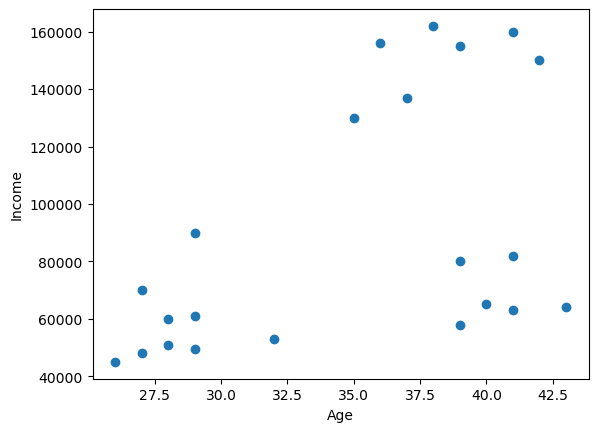

In [3]:
# visualization
plt.scatter(df.Age,df['Income($)'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

In [4]:
kmean=KMeans(n_clusters=3)
y_predicted=kmean.fit_predict(df[['Age','Income($)']])
y_predicted

C:\Users\LENOVO\anaconda34\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [5]:
df['cluster']=y_predicted

In [6]:
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [7]:
kmean.cluster_centers_

array([[3.24166667e+01, 5.72916667e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.63333333e+01, 8.40000000e+04]])

In [8]:
# plotting
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

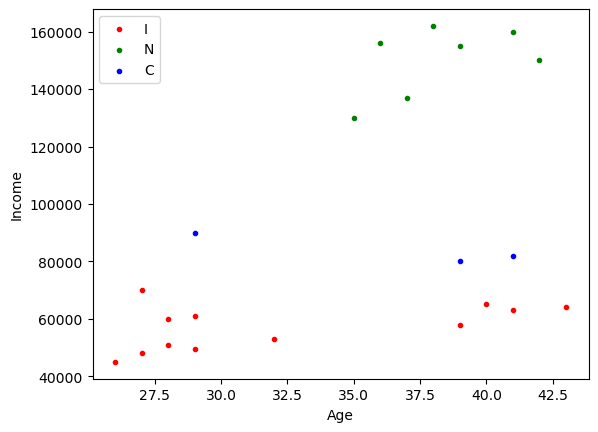

In [11]:
plt.scatter(df1.Age,df1['Income($)'],color='red',marker='.')
plt.scatter(df2.Age,df2['Income($)'],color='green',marker='.')
plt.scatter(df3.Age,df3['Income($)'],color='blue',marker='.')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend('INC')
plt.show()

In [25]:
# our scaleing is not proper becouse of that our ML model giving wrong result
# to making proper scale we use Min max scaling
# for income columns
scale=MinMaxScaler()
scale.fit(df[['Income($)']])
df['Income($)']=scale.transform(df[['Income($)']])

# for Age column
scale.fit(df[['Age']])
df["Age"]=scale.transform(df[['Age']])

In [26]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.0,0.0,0.794199
1,Michael,0.0,0.0,0.700613
2,Mohan,0.0,0.0,0.679637
3,Ismail,0.0,0.0,0.739016
4,Kory,1.0,1.0,0.700734


In [27]:
kmean=KMeans(n_clusters=3)
y_predict=kmean.fit_predict(df[['Age','Income($)']])
y_predict

C:\Users\LENOVO\anaconda34\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

In [28]:
df['cluster']=y_predict

In [30]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.0,0.0,0
1,Michael,0.0,0.0,0
2,Mohan,0.0,0.0,0
3,Ismail,0.0,0.0,0
4,Kory,1.0,1.0,1


In [31]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

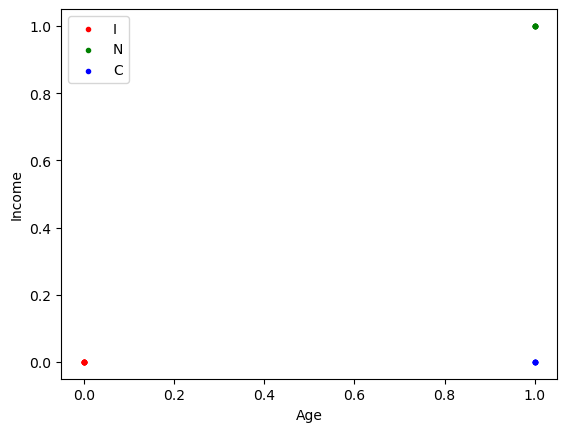

In [32]:
plt.scatter(df1.Age,df1['Income($)'],color='red',marker='.')
plt.scatter(df2.Age,df2['Income($)'],color='green',marker='.')
plt.scatter(df3.Age,df3['Income($)'],color='blue',marker='.')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend('INC')
plt.show()